In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from scipy.optimize import curve_fit
from scipy.stats import linregress
from edes.modules.detection.detection_utils import plot, plot_ax, plot_ax_errbar, plot_errbar, big_plt_font, hollow_plt_font
hollow_plt_font()

In [36]:
R = 0.985e6 

# Applied voltage (V)
V_app = np.array([200, 400, 600, 800, 1000, 1200])

# Measured voltage drop (mV)
V_meas_4K = np.array([1.2, 3.2, 5.3, 7.4, 9.9, 12.5])

temp_headers = np.array([3, 43, 113, 215])

# Column 1: Measured drop @ 43 K (mV)
V_meas_43K = np.array([1.2, 2.5, 4.1, 5.6, 7.5, 9.5])

# Column 2: Measured drop @ 113 K (mV)
V_meas_113K = np.array([11, 24, 36.6, 52, 69, 88])

# Column 3: Measured drop @ 215 K (mV)
V_meas_215K = np.array([106, 217, 331, 451, 577, 710])

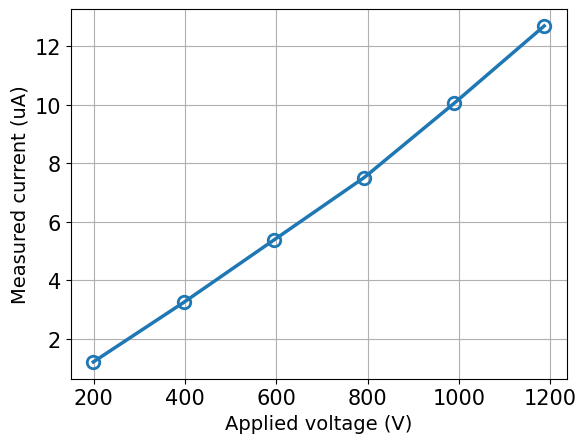

In [5]:
plot(V_app-V_meas, V_meas/R*1e6, xlabel='Applied voltage (V)', ylabel='Measured current (uA)')

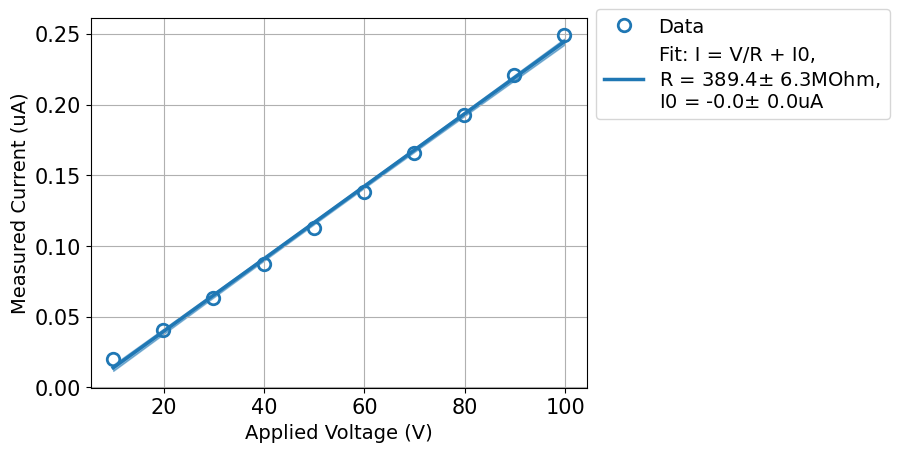

In [6]:
R = 0.983e6 

# Applied voltage (V)
V_app = np.arange(10,110,10)

# Column 3: Measured drop @ 215 K (mV)
V_meas = np.array([0.020, 0.040,
0.062,
0.086,
0.111,
0.136,
0.163,
0.189,
0.217,
0.245])
I = V_meas/R
V = V_app - V_meas

slope, intercept, r_value, p_value, std_err = linregress(V, I)

# Uncertainty region calculation using polyfit covariance
p, cov = np.polyfit(V, I, 1, cov=True)
def get_sigma(x, cov):
    return np.sqrt(cov[0,0] * x**2 + 2 * cov[0,1] * x + cov[1,1])


V_fit = np.linspace(V.min(), V.max(), 100)
I_fit = slope*V_fit + intercept
sigmas = np.array([get_sigma(x, cov) for x in V_fit])

# Plot
plot(V, I*1e6, 'o', label=f'Data')
plot(V_fit, I_fit*1e6, '-', color=f'C0', label=f'Fit: I = V/R + I0, \nR = {1/slope/1e6:.1f}$\pm$ {np.sqrt(cov[0,0])/(slope**2)/1e6:.1f}MOhm, \nI0 = {intercept*1e6:.1f}$\pm$ {np.sqrt(cov[1,1])*1e6:.1f}uA')
plt.fill_between(V_fit, (I_fit - sigmas)*1e6, (I_fit + sigmas)*1e6, color=f'C0', alpha=0.5)
plt.xlabel('Applied Voltage (V)')
plt.ylabel('Measured Current (uA)')
plt.legend(bbox_to_anchor=(1,1.05))
plt.show()

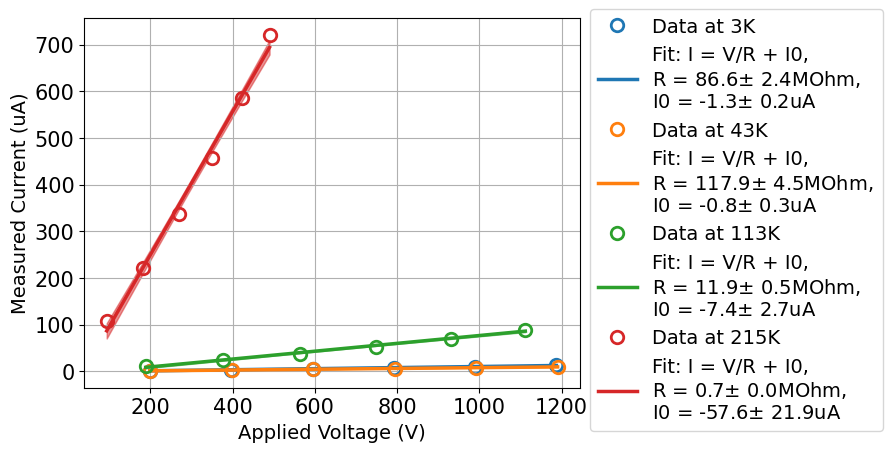

In [40]:
all_V = [V_meas_4K, V_meas_43K, V_meas_113K, V_meas_215K]
for i in range(4): 
    V_meas = all_V[i]
    I = V_meas/R
    V = V_app - V_meas
    
    slope, intercept, r_value, p_value, std_err = linregress(V, I)
    
    # Uncertainty region calculation using polyfit covariance
    p, cov = np.polyfit(V, I, 1, cov=True)
    def get_sigma(x, cov):
        return np.sqrt(cov[0,0] * x**2 + 2 * cov[0,1] * x + cov[1,1])
    
    
    V_fit = np.linspace(V.min(), V.max(), 100)
    I_fit = slope*V_fit + intercept
    sigmas = np.array([get_sigma(x, cov) for x in V_fit])
    
    # Plot
    plot(V, I*1e6, 'o', label=f'Data at {temp_headers[i]}K')
    plot(V_fit, I_fit*1e6, '-', color=f'C{i}', label=f'Fit: I = V/R + I0, \nR = {1/slope/1e6:.1f}$\pm$ {np.sqrt(cov[0,0])/(slope**2)/1e6:.1f}MOhm, \nI0 = {intercept*1e6:.1f}$\pm$ {np.sqrt(cov[1,1])*1e6:.1f}uA')
    plt.fill_between(V_fit, (I_fit - sigmas)*1e6, (I_fit + sigmas)*1e6, color=f'C{i}', alpha=0.5)
plt.xlabel('Applied Voltage (V)')
plt.ylabel('Measured Current (uA)')
plt.legend(bbox_to_anchor=(1,1.05))
plt.show()